# 事前準備：データのダウンロード
以下を実行して、外部ファイルをダウンロードしてください。   
**このセルはColaboratoryを起動するたびに必要となります**

In [1]:
import urllib.request
!mkdir fig sound
urllib.request.urlretrieve('https://park.itc.u-tokyo.ac.jp/yamakata-lab/lecture/mediaproc/mediaproc2/sound/ex-Violin.wav', './sound/ex-Violin.wav')
urllib.request.urlretrieve('https://park.itc.u-tokyo.ac.jp/yamakata-lab/lecture/mediaproc/mediaproc2/sound/ex-Violin-music.wav', './sound/ex-Violin-music.wav')

('./sound/ex-Violin-music.wav', <http.client.HTTPMessage at 0x75cefa2a56d0>)

# 音の情報処理 課題：楽器の音を分析しよう

**課題は図が描画されている状態で保存して提出してください！**

## 課題１：パワースペクトルの描画

`sound/ex-Violin.wav`を開いて、その波形のパワースペクトルを描画し、このノートブックが置かれているディレクトリ内に`ex2_1.png`という名前の画像として保存してください。   
- サンプリングレートはwaveオブジェクトから`wave.getframerate()`を使って受け取ってください。   
- 横軸は周波数（単位はHz)、縦軸は振幅（単位はdB）としてください。デシベル計算の基準値 は$p_0 = 1$として計算してください。
- 軸メモリと軸ラベルを付けてください。   

次のようなグラフになったら正解です。
<img src="https://park.itc.u-tokyo.ac.jp/yamakata-lab/lecture/mediaproc/mediaproc2/fig/ex2_ans1.png" width="640">

ちなみにこれはこんな音のパワースペクトルです。

In [2]:
import IPython
IPython.display.Audio('sound/ex-Violin.wav')

In [ ]:
######### mp_ex2-1 ########## この行は削除しないでください！

%matplotlib inline
import wave
import numpy as np
import matplotlib.pyplot as plt

wavfile = wave.open('sound/ex-Violin.wav', 'rb')
x = wavfile.readframes(wavfile.getnframes())
sampling_rate = wavfile.getframerate()
sample_size = wavfile.getsampwidth()
wavfile.close()


# ここにコードを書いて下さい
x = np.frombuffer(x, dtype="int16")                 # bytes → int16 array
x = x / (2 ** (8 * sample_size) / 2)  
X = np.fft.fft(x)
amplitude = 20 * np.log10(np.abs(X) + 1e-10)        # +1e-10 avoids log(0) = -inf           


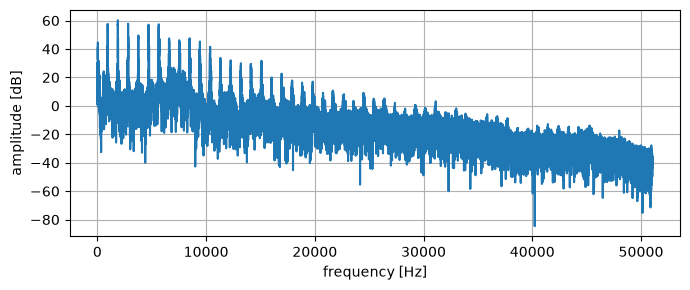

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 3))
ax = plt.subplot()
ax.plot(amplitude[0:int(len(X)/2)])
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("amplitude [dB]")
ax.grid()
fig.tight_layout()
plt.savefig('ex2_1.png')  

## 課題２：スペクトログラムの描画

ヴァイオリンの音楽`sound/Violin-music.wav`のスペクトログラムを描画し、このノートブックが置かれているディレクトリ内に`ex2_2.png`という名前の画像として保存してください。   
スペクトログラム計算時のパラメータは以下の通りです。
- 窓幅は512
- 移動窓における重なり（オーバーラップ）は32フレーム
- 窓関数はハニング窓

次のようなグラフになったらOKです。
<img src="https://park.itc.u-tokyo.ac.jp/yamakata-lab/lecture/mediaproc/mediaproc2/fig/ex2_2_2026S2.png" width="640">


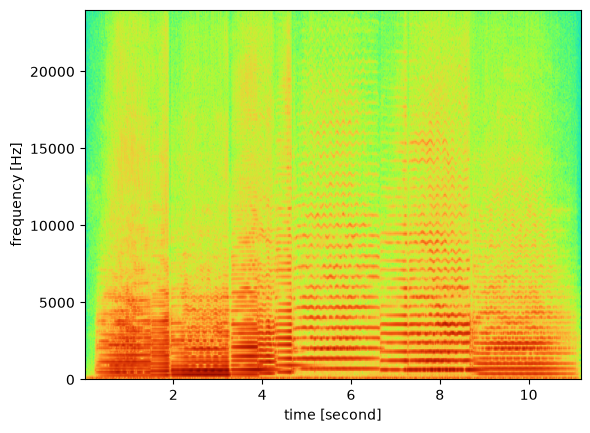

In [9]:
%matplotlib inline
import wave
import numpy as np
import matplotlib.pyplot as plt

wavfile = wave.open("sound/ex-Violin-music.wav", "rb")
x = wavfile.readframes(wavfile.getnframes())
x = np.frombuffer(x, dtype="int16")
sampling_rate = wavfile.getframerate()
wavfile.close()


# ここにコードを書いて下さい
# 短く切り出すときの窓幅（切り出すフレームの数）
N = 512

# FFTで用いるハミング窓
hammingWindow = np.hamming(N)

# スペクトログラムを描画
# cmap
pxx, freqs, bins, im = plt.specgram(x,# 元の波形
                                NFFT=N, # 切り出す幅
                                Fs=sampling_rate, # サンプリングレート
                                noverlap=N//2, # 0から順番に切り出していくとき、重複して切り出すならここで重複させるフレーム数を指定
                                window=hammingWindow, # 窓関数の指定
                                            # 窓関数には他にも様々なものが用意されています。
                                            # 参照：https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.specgram.html
                                cmap='turbo') # カラーマップ：値の大きさによって色を塗り分ける。
                                            # 様々なカラーマップが用意されている。
                                            # 参照：https://matplotlib.org/examples/color/colormaps_reference.html

#axis([0, length, 0, wf.getframerate() / 2])
plt.xlabel("time [second]")
plt.ylabel("frequency [Hz]")
plt.savefig('fig/SoundProcessing4-1.png') # 図を画像として保存


ちなみにこれはこんな音のスペクトログラムです。

In [10]:
import IPython
IPython.display.Audio('sound/ex-Violin-music.wav')

<!-- label: 2026S -->